
# SYE6105 项目（数据集 A）

本 Notebook 使用 NASA C-MAPSS（FD001）完成风险建模交付：
- RUL 回归预测（含 RMSE 与预测区间）；
- 30 周期内失效风险分类（含 Recall、AUC-PR 与混淆矩阵）；
- 可视化：传感器趋势、混淆矩阵、特征重要性。



## 1. 依赖与随机种子
本 Notebook 为**自包含代码**：包含数据读取、特征工程、建模、评估与可视化全流程。


In [1]:

import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    recall_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')



## 2. 数据加载（dataset_A.zip 内嵌压缩包）


In [2]:

ROOT_ZIP = Path('dataset_A.zip')
SUBSET = 'FD001'

base_cols = ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
ALL_COLS = base_cols + sensor_cols

def load_cmapss_subset(root_zip: Path, subset: str = 'FD001'):
    with zipfile.ZipFile(root_zip, 'r') as outer:
        inner_zip_name = [n for n in outer.namelist() if n.endswith('.zip')][0]
        inner_data = outer.read(inner_zip_name)

    with zipfile.ZipFile(io.BytesIO(inner_data), 'r') as inner:
        def read_df(file_name):
            text = inner.read(file_name).decode('utf-8', errors='ignore')
            return pd.read_csv(io.StringIO(text), sep=r'\s+', header=None)

        train = read_df(f'train_{subset}.txt')
        test = read_df(f'test_{subset}.txt')
        rul = read_df(f'RUL_{subset}.txt')

    train = train.iloc[:, :len(ALL_COLS)]
    test = test.iloc[:, :len(ALL_COLS)]
    train.columns = ALL_COLS
    test.columns = ALL_COLS

    max_cycle_train = train.groupby('unit')['cycle'].transform('max')
    train['RUL'] = max_cycle_train - train['cycle']

    max_cycle_test = test.groupby('unit')['cycle'].max().reset_index()
    max_cycle_test['final_rul'] = rul.iloc[:, 0].values
    test = test.merge(max_cycle_test, on='unit', how='left')
    test['RUL'] = test['cycle_y'] + test['final_rul'] - test['cycle_x']
    test = test.drop(columns=['cycle_y', 'final_rul']).rename(columns={'cycle_x': 'cycle'})

    return train, test

train_df, test_df = load_cmapss_subset(ROOT_ZIP, SUBSET)
print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
train_df.head()


train shape: (20631, 27)
test shape : (13096, 27)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187



## 3. 风险任务定义
- 分类任务：30 周期内是否失效（`fail_within_30`）
- 回归任务：连续 RUL 预测


In [3]:

N_HORIZON = 30
train_df['fail_within_30'] = (train_df['RUL'] <= N_HORIZON).astype(int)
test_df['fail_within_30'] = (test_df['RUL'] <= N_HORIZON).astype(int)

print('Train positive ratio:', train_df['fail_within_30'].mean().round(4))
print('Test positive ratio :', test_df['fail_within_30'].mean().round(4))


Train positive ratio: 0.1503
Test positive ratio : 0.0254



## 4. 特征工程（趋势 + 滞后）
工程原则：保留有效传感器并构造时间依赖特征，体现风险演化过程。


In [4]:

feature_candidates = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + sensor_cols
nunique = train_df[feature_candidates].nunique()
usable_features = nunique[nunique > 1].index.tolist()

sensor_variance = train_df[sensor_cols].var().sort_values(ascending=False)
top_sensors = [s for s in sensor_variance.index if s in usable_features][:8]

def add_time_features(df):
    out = df.copy().sort_values(['unit', 'cycle'])
    g = out.groupby('unit')

    for c in top_sensors:
        out[f'{c}_rollmean_5'] = g[c].transform(lambda x: x.rolling(5, min_periods=1).mean())
        out[f'{c}_rollstd_5'] = g[c].transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0.0))
        out[f'{c}_lag1'] = g[c].shift(1).bfill()

    return out

train_fe = add_time_features(train_df)
test_fe = add_time_features(test_df)

base_used = [c for c in usable_features if c in train_fe.columns]
extra_feats = [c for c in train_fe.columns if c.endswith('_rollmean_5') or c.endswith('_rollstd_5') or c.endswith('_lag1')]
FEATURES = base_used + extra_feats

print('usable base features:', len(base_used))
print('extra time features:', len(extra_feats))
print('total features     :', len(FEATURES))


usable base features: 17
extra time features: 24
total features     : 41



## 5. 可视化一：关键传感器趋势


/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 21629 (\N{CJK UNIFIED IDEOGRAPH-547D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4818/3605704792.py:17: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}

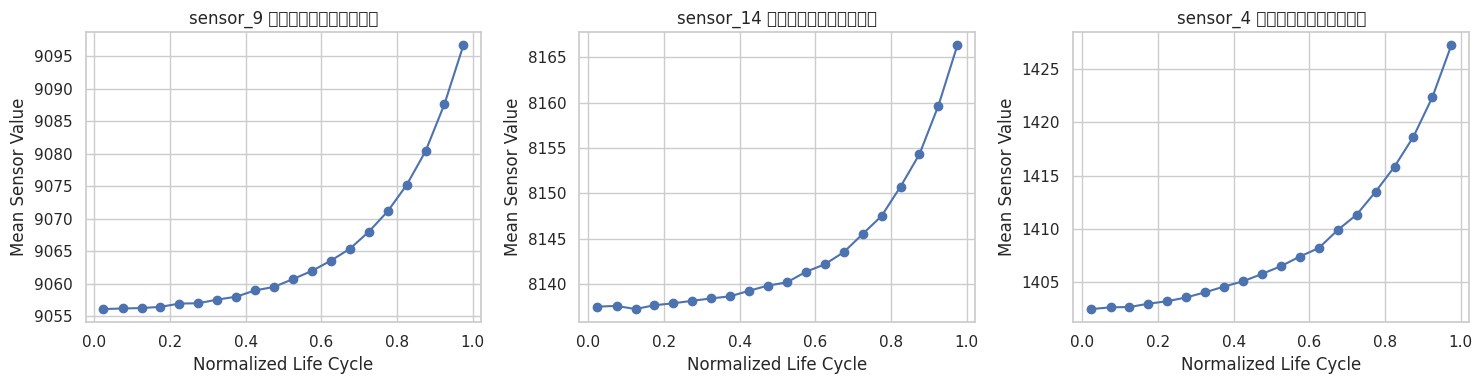

In [5]:

plot_sensors = top_sensors[:3]
trend = train_fe[['unit', 'cycle'] + plot_sensors].copy()
trend['life_pct'] = trend['cycle'] / trend.groupby('unit')['cycle'].transform('max')
trend['life_bin'] = pd.cut(trend['life_pct'], bins=np.linspace(0, 1, 21), include_lowest=True)
trend_mean = trend.groupby('life_bin')[plot_sensors].mean().reset_index()
trend_mean['life_center'] = [interval.mid for interval in trend_mean['life_bin']]

fig, axes = plt.subplots(1, len(plot_sensors), figsize=(5*len(plot_sensors), 4), sharex=True)
if len(plot_sensors) == 1:
    axes = [axes]

for ax, s in zip(axes, plot_sensors):
    ax.plot(trend_mean['life_center'], trend_mean[s], marker='o')
    ax.set_title(f'{s} 趋势（生命周期归一化）')
    ax.set_xlabel('Normalized Life Cycle')
    ax.set_ylabel('Mean Sensor Value')
plt.tight_layout()
plt.show()



## 6. 训练/验证划分（按 unit 分组，避免泄漏）


In [6]:

X = train_fe[FEATURES]
y_cls = train_fe['fail_within_30']
y_rul = train_fe['RUL']
groups = train_fe['unit']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(X, y_cls, groups=groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train_cls, y_val_cls = y_cls.iloc[train_idx], y_cls.iloc[val_idx]
y_train_rul, y_val_rul = y_rul.iloc[train_idx], y_rul.iloc[val_idx]

print('Train rows:', len(train_idx), 'Val rows:', len(val_idx))


Train rows: 16561 Val rows: 4070



## 7. 分类建模（至少两种算法）


In [7]:

clf_models = {
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=160,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
}

clf_results = []
for name, model in clf_models.items():
    model.fit(X_train, y_train_cls)
    prob = model.predict_proba(X_val)[:, 1]
    pred = (prob >= 0.5).astype(int)
    clf_results.append({
        'model': name,
        'Recall': recall_score(y_val_cls, pred),
        'AUC-PR': average_precision_score(y_val_cls, prob),
        'ROC-AUC': roc_auc_score(y_val_cls, prob),
    })

clf_results_df = pd.DataFrame(clf_results).sort_values('AUC-PR', ascending=False)
clf_results_df


,model,Recall,AUC-PR,ROC-AUC
1,LogisticRegression,0.969355,0.96155,0.991742
0,RandomForestClassifier,0.882258,0.96087,0.991088



## 8. 回归建模（至少两种算法）


In [8]:

reg_models = {
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=160,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train, y_train_rul)
    pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_rul, pred))
    reg_results.append({'model': name, 'RMSE': rmse})

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE')
reg_results_df


,model,RMSE
1,GradientBoostingRegressor,34.221716
0,RandomForestRegressor,34.245022



## 9. 测试集评估：混淆矩阵 + 特征重要性 + 不确定性


Best classifier: LogisticRegression
Test Recall: 0.8133
Test AUC-PR: 0.7934


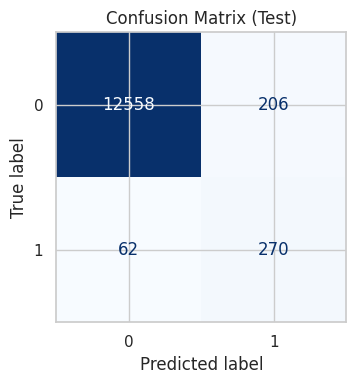

/tmp/ipykernel_4818/2372447246.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, ax=ax, palette='viridis')


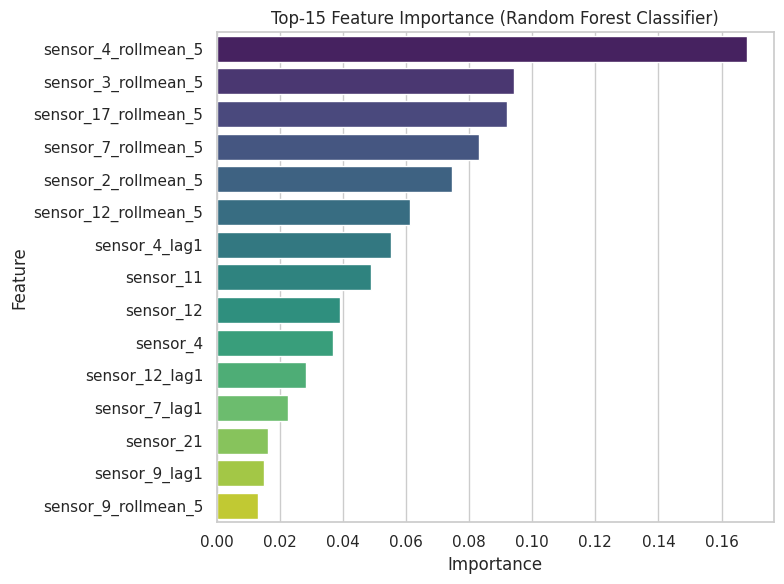

In [9]:

best_clf_name = clf_results_df.iloc[0]['model']
best_clf = clf_models[best_clf_name]
best_clf.fit(train_fe[FEATURES], train_fe['fail_within_30'])

X_test = test_fe[FEATURES]
y_test_cls = test_fe['fail_within_30']

test_prob = best_clf.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print('Best classifier:', best_clf_name)
print('Test Recall:', round(recall_score(y_test_cls, test_pred), 4))
print('Test AUC-PR:', round(average_precision_score(y_test_cls, test_prob), 4))

cm = confusion_matrix(y_test_cls, test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Test)')
plt.tight_layout()
plt.show()

rf_for_importance = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_for_importance.fit(train_fe[FEATURES], train_fe['fail_within_30'])
imp = pd.Series(rf_for_importance.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, ax=ax, palette='viridis')
ax.set_title('Top-15 Feature Importance (Random Forest Classifier)')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


In [10]:

best_reg_name = reg_results_df.iloc[0]['model']
best_reg = reg_models[best_reg_name]
best_reg.fit(train_fe[FEATURES], train_fe['RUL'])

y_test_rul = test_fe['RUL']
y_test_pred = best_reg.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test_rul, y_test_pred))
print('Best regressor:', best_reg_name)
print('Test RMSE:', round(rmse_test, 4))

if isinstance(best_reg, RandomForestRegressor):
    tree_preds = np.stack([est.predict(X_test) for est in best_reg.estimators_], axis=1)
    pred_p05 = np.percentile(tree_preds, 5, axis=1)
    pred_p95 = np.percentile(tree_preds, 95, axis=1)
    coverage = ((y_test_rul >= pred_p05) & (y_test_rul <= pred_p95)).mean()
    print('Approx. 90% prediction interval coverage:', round(float(coverage), 4))


Best regressor: GradientBoostingRegressor
Test RMSE: 45.3223



## 10. 结论（工程决策视角）
- 分类模型输出的失效概率可直接用于维护优先级排序；
- 特征重要性揭示了主要风险驱动传感器，可用于状态监测阈值设计；
- RUL 回归与预测区间可用于维护窗口和备件策略评估。
